# 자동차 도장 건조공정 - 설비 이상 탐지
## LSTM-AutoEncoder 기반 건조로(Oven) 예지보전

**시나리오**: 자동차 도장 후 건조 공정 (130°C → 90°C)

**원본**: KAMP 열풍건조 센서 데이터를 자동차 도장 건조 조건으로 변환

**목표**: 건조로 온도/전류 데이터 기반 설비 이상 조기 탐지

## 1. 라이브러리 및 환경 설정

In [1]:
import pandas as pd
import numpy as np
import os, glob
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

## 2. 원본 데이터 로딩 및 자동차 공정 변환

### 변환 근거
| 구분 | KAMP 원본 (도금 열풍건조) | 자동차 도장 건조 |
|---|---|---|
| 온도 범위 | ~64°C ~ 134°C | 90°C ~ 130°C |
| 건조 목적 | 도금 피막 안정화 | 도장 도막 경화 |
| 설비 | 열풍건조기 | 건조로(Oven) |
| 위험 요소 | 과열로 인한 설비 고장 | 온도 불균형, 히터 고장 |

In [2]:
# 원본 KAMP 센서 데이터 로딩
data_path = 'dataset/data_18/5공정_180sec'
csv_files = sorted(glob.glob(os.path.join(data_path, 'kemp-abh-sensor-*.csv')))

df_list = []
for f in csv_files:
    temp_df = pd.read_csv(f, encoding='utf-8')
    df_list.append(temp_df)

df_raw = pd.concat(df_list, ignore_index=True)
print(f'원본 데이터 shape: {df_raw.shape}')
print(f'원본 온도 범위: {df_raw["Temp"].min():.1f}°C ~ {df_raw["Temp"].max():.1f}°C')
print(f'원본 전류 범위: {df_raw["Current"].min():.3f}A ~ {df_raw["Current"].max():.3f}A')

원본 데이터 shape: (51084, 6)
원본 온도 범위: 64.0°C ~ 134.2°C
원본 전류 범위: 0.837A ~ 2.061A


In [3]:
# 자동차 도장 건조 조건으로 변환
df = df_raw.copy()

# --- 온도 변환: 원본 범위 → 90~130°C ---
temp_min_orig = df_raw['Temp'].min()
temp_max_orig = df_raw['Temp'].max()

# 선형 변환: 자동차 건조로 온도 범위
AUTO_TEMP_MIN = 90.0   # 건조 시작/종료 최저 온도
AUTO_TEMP_MAX = 130.0  # 건조 피크 온도

df['Temp'] = AUTO_TEMP_MIN + (df_raw['Temp'] - temp_min_orig) / (temp_max_orig - temp_min_orig) * (AUTO_TEMP_MAX - AUTO_TEMP_MIN)

# --- 전류 변환: 자동차 건조로 히터 전류 (더 높은 범위) ---
curr_min_orig = df_raw['Current'].min()
curr_max_orig = df_raw['Current'].max()

AUTO_CURR_MIN = 15.0   # 히터 최소 전류 (A)
AUTO_CURR_MAX = 25.0   # 히터 최대 전류 (A)

df['Current'] = AUTO_CURR_MIN + (df_raw['Current'] - curr_min_orig) / (curr_max_orig - curr_min_orig) * (AUTO_CURR_MAX - AUTO_CURR_MIN)

# 약간의 현실적 노이즈 추가
np.random.seed(42)
df['Temp'] += np.random.normal(0, 0.3, len(df))
df['Current'] += np.random.normal(0, 0.1, len(df))

# 컬럼 이름 변경 (자동차 도장 공정 맥락)
df = df.rename(columns={
    'Process': 'Zone',       # 건조로 구간(Zone)
    'Temp': 'Oven_Temp',     # 건조로 온도
    'Current': 'Heater_Curr' # 히터 전류
})

print(f'\n=== 변환 후 (자동차 도장 건조) ===')
print(f'건조로 온도 범위: {df["Oven_Temp"].min():.1f}°C ~ {df["Oven_Temp"].max():.1f}°C')
print(f'히터 전류 범위: {df["Heater_Curr"].min():.1f}A ~ {df["Heater_Curr"].max():.1f}A')
df.head()


=== 변환 후 (자동차 도장 건조) ===
건조로 온도 범위: 89.2°C ~ 130.1°C
히터 전류 범위: 14.8A ~ 24.7A


,Index,Zone,Time,Oven_Temp,Heater_Curr,Date
0,1,1,오후 4:24:03.0,96.493378,21.214953,2021-09-06
1,2,1,오후 4:24:08.0,97.169948,20.755942,2021-09-06
2,3,1,오후 4:24:13.0,97.700538,22.125398,2021-09-06
3,4,1,오후 4:24:18.0,97.626167,22.331181,2021-09-06
4,5,1,오후 4:24:23.0,97.834639,22.523433,2021-09-06


In [4]:
# Error Lot → 불량 Vehicle Lot으로 변환
error_lot_df = pd.read_csv(os.path.join(data_path, 'Error Lot list.csv'), encoding='cp949')
error_lot_df.columns = ['Date'] + [f'Error_Lot_{i}' for i in range(1, 12)]

error_dict = {}
for _, row in error_lot_df.iterrows():
    date = row['Date']
    lots = [int(v) for v in row[1:].dropna().values]
    if lots:
        error_dict[date] = lots

# 라벨 생성
df['label'] = 0
for idx, row in df.iterrows():
    date = row['Date']
    zone = row['Zone']
    if date in error_dict and zone in error_dict[date]:
        df.at[idx, 'label'] = 1

normal_count = (df['label'] == 0).sum()
error_count = (df['label'] == 1).sum()
print(f'정상 가동: {normal_count:,}건')
print(f'이상 가동: {error_count:,}건')
print(f'이상 비율: {error_count / len(df) * 100:.2f}%')

정상 가동: 47,088건
이상 가동: 3,996건
이상 비율: 7.82%


## 3. 탐색적 데이터 분석 (EDA)

자동차 도장 건조로의 온도 및 히터 전류 패턴을 확인합니다.

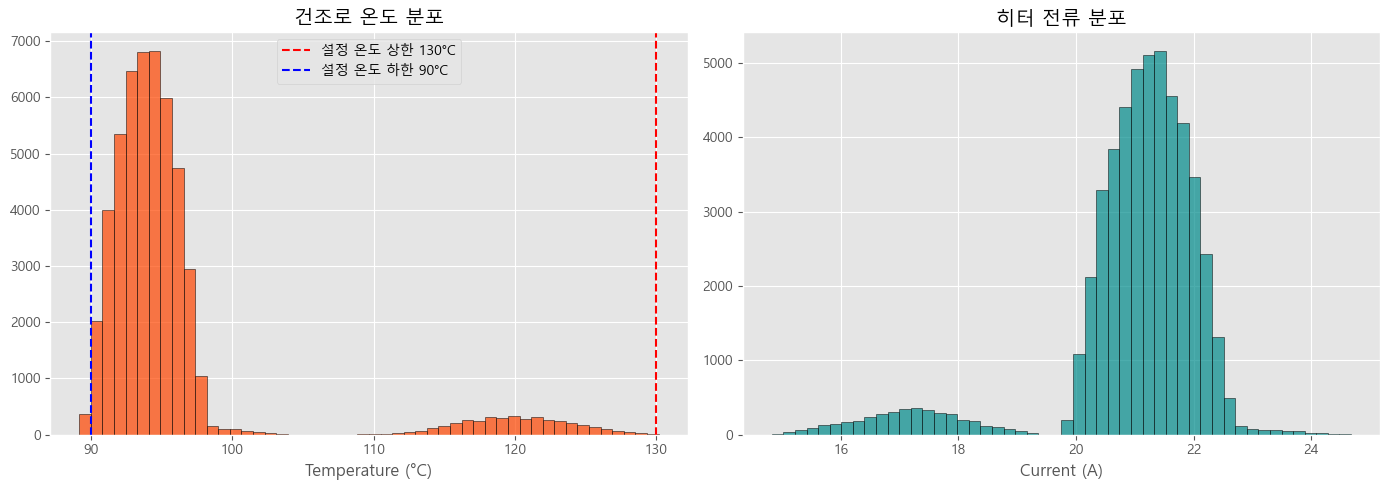

In [5]:
# 온도 / 히터 전류 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Oven_Temp'], bins=50, color='orangered', edgecolor='black', alpha=0.7)
axes[0].set_title('건조로 온도 분포', fontsize=14)
axes[0].set_xlabel('Temperature (°C)')
axes[0].axvline(x=130, color='red', linestyle='--', label='설정 온도 상한 130°C')
axes[0].axvline(x=90, color='blue', linestyle='--', label='설정 온도 하한 90°C')
axes[0].legend()

axes[1].hist(df['Heater_Curr'], bins=50, color='darkcyan', edgecolor='black', alpha=0.7)
axes[1].set_title('히터 전류 분포', fontsize=14)
axes[1].set_xlabel('Current (A)')

plt.tight_layout()
plt.show()

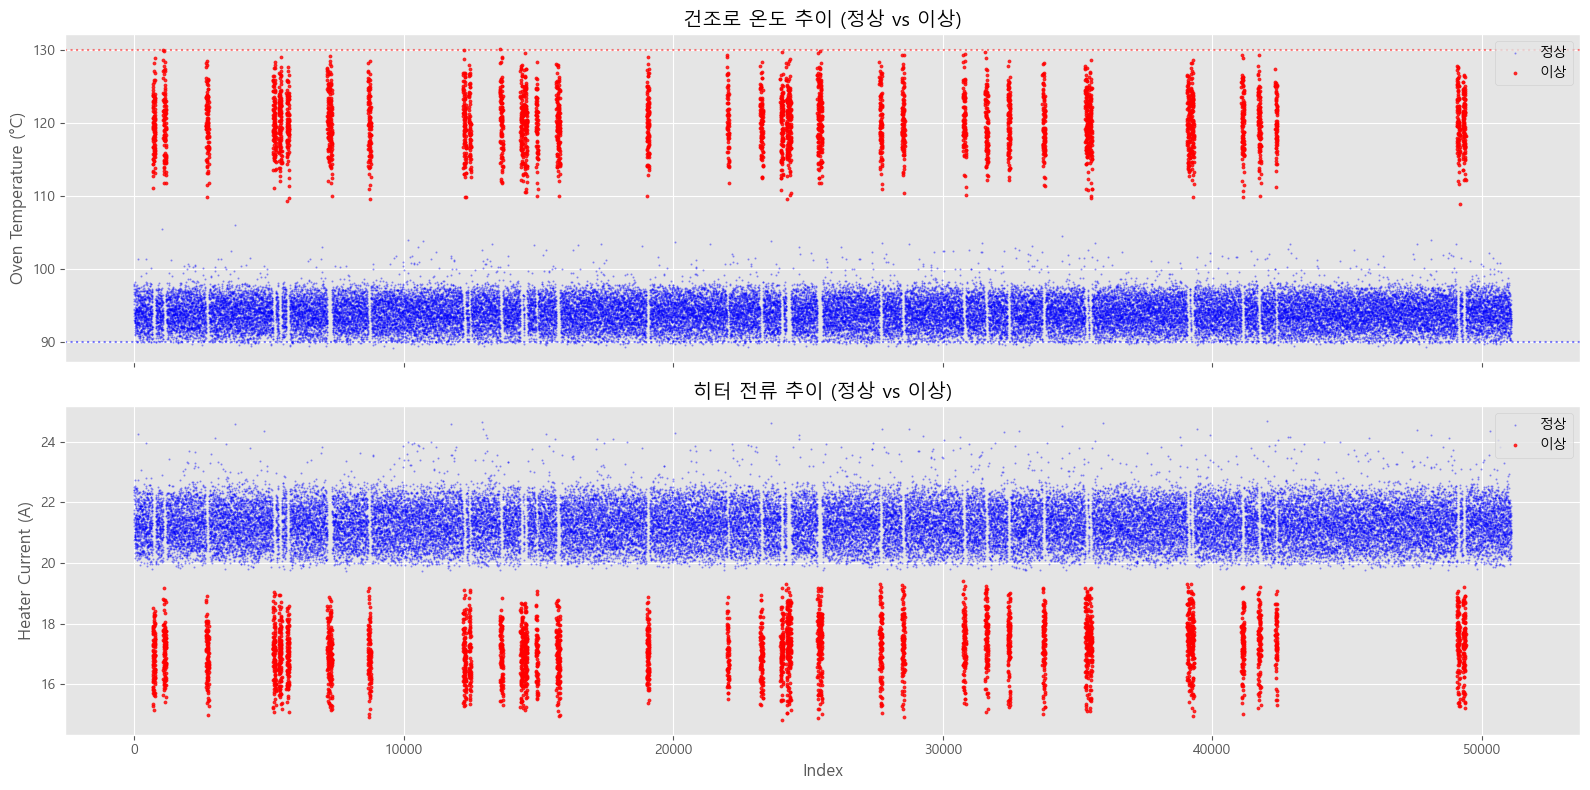

In [6]:
# 시계열 추이 - 건조로 온도 + 히터 전류
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

normal = df[df['label'] == 0]
error = df[df['label'] == 1]

# 온도
axes[0].scatter(normal.index, normal['Oven_Temp'], s=1, alpha=0.3, color='blue', label='정상')
axes[0].scatter(error.index, error['Oven_Temp'], s=5, alpha=0.8, color='red', label='이상')
axes[0].axhline(y=130, color='red', linestyle=':', alpha=0.5)
axes[0].axhline(y=90, color='blue', linestyle=':', alpha=0.5)
axes[0].set_ylabel('Oven Temperature (°C)', fontsize=12)
axes[0].set_title('건조로 온도 추이 (정상 vs 이상)', fontsize=14)
axes[0].legend(loc='upper right')

# 전류
axes[1].scatter(normal.index, normal['Heater_Curr'], s=1, alpha=0.3, color='blue', label='정상')
axes[1].scatter(error.index, error['Heater_Curr'], s=5, alpha=0.8, color='red', label='이상')
axes[1].set_ylabel('Heater Current (A)', fontsize=12)
axes[1].set_title('히터 전류 추이 (정상 vs 이상)', fontsize=14)
axes[1].set_xlabel('Index')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

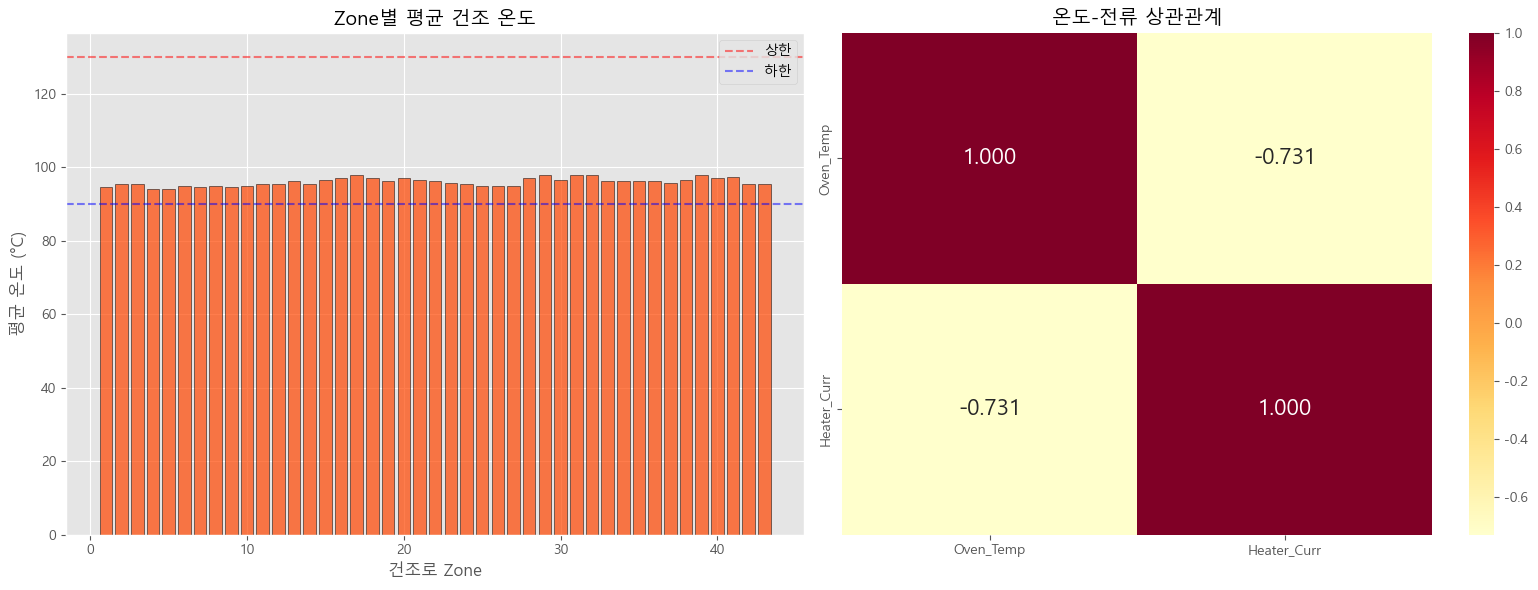

In [7]:
# 건조로 Zone별 온도 프로파일
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Zone별 평균 온도 (건조로 구간별 온도 프로파일)
zone_temp = df.groupby('Zone')['Oven_Temp'].mean()
axes[0].bar(zone_temp.index, zone_temp.values, color='orangered', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('건조로 Zone', fontsize=12)
axes[0].set_ylabel('평균 온도 (°C)', fontsize=12)
axes[0].set_title('Zone별 평균 건조 온도', fontsize=14)
axes[0].axhline(y=130, color='red', linestyle='--', alpha=0.5, label='상한')
axes[0].axhline(y=90, color='blue', linestyle='--', alpha=0.5, label='하한')
axes[0].legend()

# 상관관계
corr = df[['Oven_Temp', 'Heater_Curr']].corr()
sns.heatmap(corr, annot=True, cmap='YlOrRd', fmt='.3f', annot_kws={'size': 16}, ax=axes[1])
axes[1].set_title('온도-전류 상관관계', fontsize=14)

plt.tight_layout()
plt.show()

## 4. 데이터 전처리

In [8]:
from sklearn.preprocessing import MinMaxScaler

features = ['Oven_Temp', 'Heater_Curr']

# 정상 데이터만 추출
normal_data = df[df['label'] == 0][features].values

# 스케일러 학습
scaler = MinMaxScaler()
normal_scaled = scaler.fit_transform(normal_data)

print(f'정상 데이터 shape: {normal_scaled.shape}')

정상 데이터 shape: (47088, 2)


In [9]:
# 시퀀스 생성
TIME_STEPS = 30

def create_sequences(data, time_steps=TIME_STEPS):
    X = []
    for i in range(len(data) - time_steps):
        X.append(data[i:i + time_steps])
    return np.array(X)

# 학습 / 검증 분리
split_idx = int(len(normal_scaled) * 0.8)
train_data = normal_scaled[:split_idx]
val_data = normal_scaled[split_idx:]

X_train = create_sequences(train_data)
X_val = create_sequences(val_data)

# 전체 데이터 → 테스트
all_data = df[features].values
all_scaled = scaler.transform(all_data)
X_test = create_sequences(all_scaled)
test_labels = df['label'].values[TIME_STEPS:]

print(f'X_train: {X_train.shape}')
print(f'X_val:   {X_val.shape}')
print(f'X_test:  {X_test.shape}')
print(f'정상: {(test_labels==0).sum()}, 이상: {(test_labels==1).sum()}')

X_train: (37640, 30, 2)
X_val:   (9388, 30, 2)
X_test:  (51054, 30, 2)
정상: 47058, 이상: 3996


## 5. LSTM-AutoEncoder 모델

자동차 건조로 센서 데이터에 맞춘 LSTM-AE 모델

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    # Encoder
    LSTM(64, input_shape=(TIME_STEPS, n_features), return_sequences=True),
    LSTM(32, return_sequences=False),
    # Bottleneck
    RepeatVector(TIME_STEPS),
    # Decoder
    LSTM(32, return_sequences=True),
    LSTM(64, return_sequences=True),
    # Output
    TimeDistributed(Dense(n_features))
])

model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 32)         │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 30, 2)          │           130 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,850 (245.51 KB)

 Trainable params: 62,850 (245.51 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# 모델 학습
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, X_train,
    epochs=50,
    batch_size=64,
    validation_data=(X_val, X_val),
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)

Epoch 1/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - loss: 0.0105 - val_loss: 0.0060
Epoch 2/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 3/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0052 - val_loss: 0.0051
Epoch 4/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0049 - val_loss: 0.0049
Epoch 5/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0046 - val_loss: 0.0047
Epoch 6/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0044 - val_loss: 0.0045
Epoch 7/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0043 - val_loss: 0.0043
Epoch 8/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0042 - val_loss: 0.0041
Epoch 9/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 10/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 11/50
589/589 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.0038 - val_loss: 0.0040
Epoch 12/50
589/589 ━━━━━━━━━━

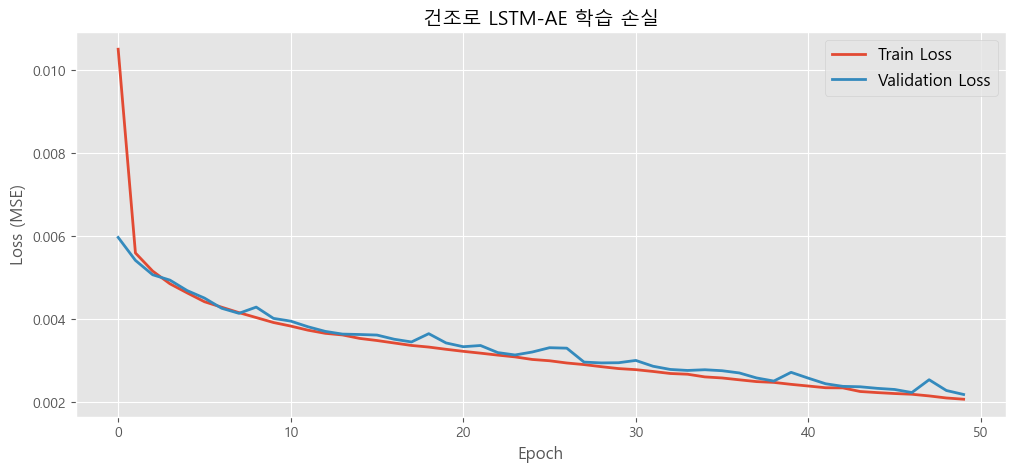

In [12]:
# 학습 손실 시각화
plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('건조로 LSTM-AE 학습 손실', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

## 6. 이상 탐지

In [13]:
# Reconstruction Error 계산
X_pred = model.predict(X_test, verbose=0)
mse = np.mean(np.power(X_test - X_pred, 2), axis=(1, 2))

error_result = pd.DataFrame({
    'reconstruction_error': mse,
    'true_class': test_labels
})

print('=== Reconstruction Error 통계 ===')
print(error_result.groupby('true_class')['reconstruction_error'].describe())

=== Reconstruction Error 통계 ===
              count      mean       std       min       25%       50%  \
true_class                                                              
0           47058.0  0.019592  0.134667  0.000618  0.001460  0.001762   
1            3996.0  1.407927  0.434797  0.001004  1.449759  1.586904   

                 75%       max  
true_class                      
0           0.002325  1.663436  
1           1.654189  1.846853  


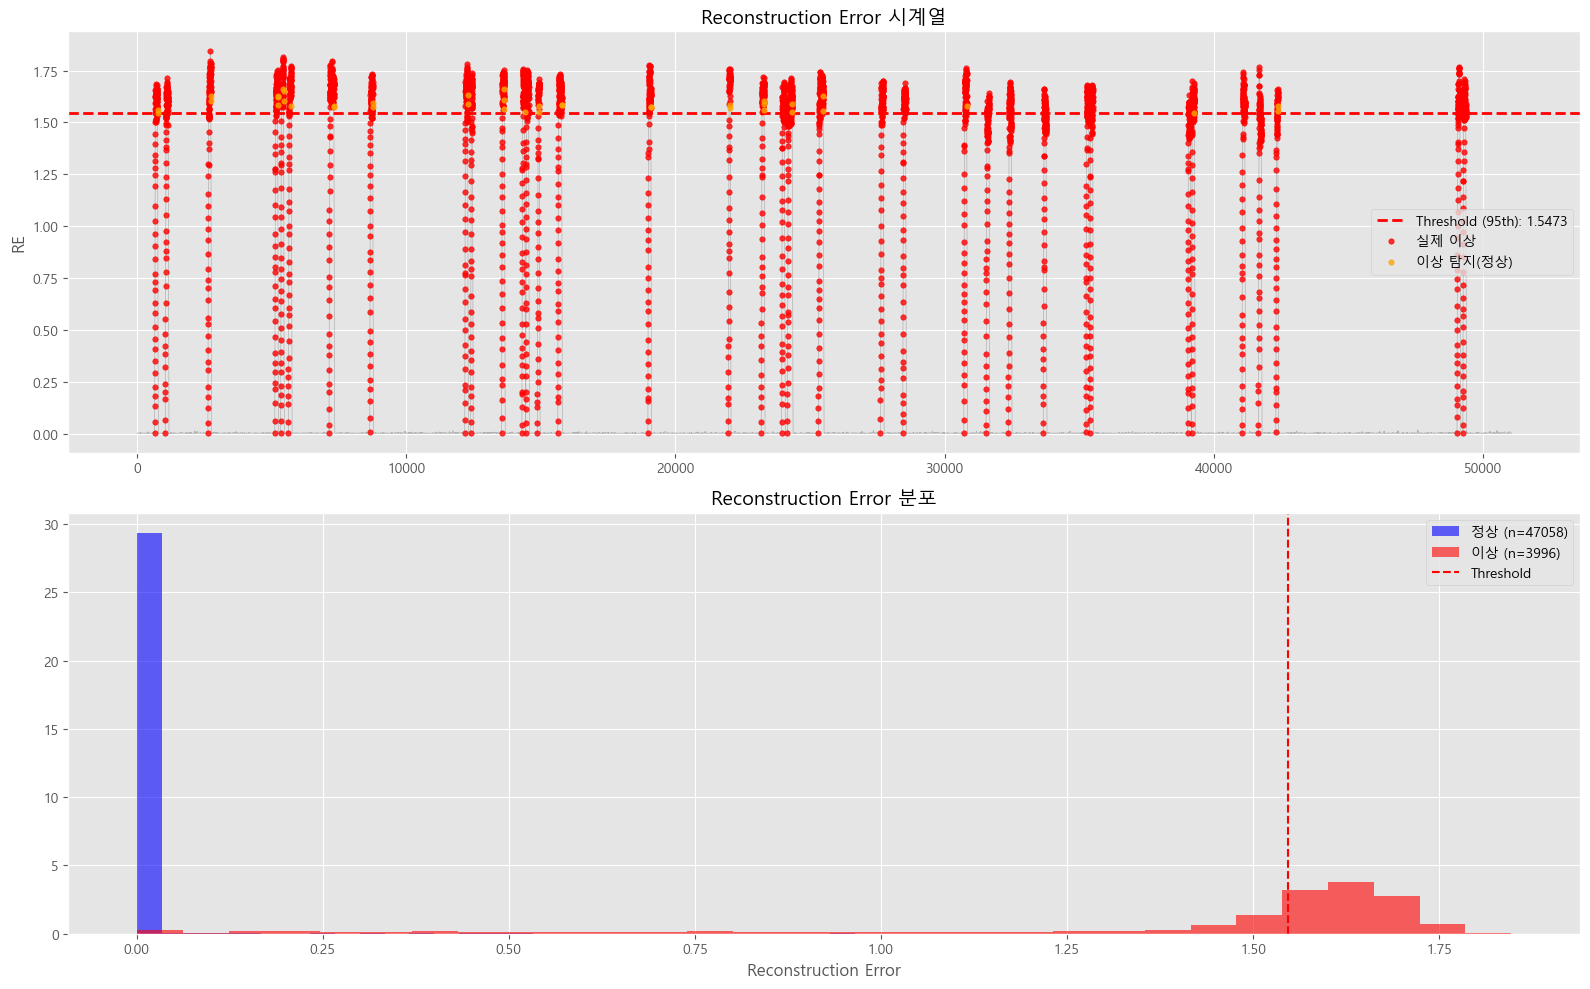

In [14]:
# Reconstruction Error 시각화
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# RE 시계열 + Threshold
threshold_95 = np.percentile(mse, 95)
axes[0].plot(error_result.index, error_result['reconstruction_error'],
             alpha=0.5, linewidth=0.5, color='gray')
axes[0].axhline(y=threshold_95, color='red', linestyle='--', linewidth=2,
                label=f'Threshold (95th): {threshold_95:.4f}')

error_points = error_result[error_result['true_class'] == 1]
axes[0].scatter(error_points.index, error_points['reconstruction_error'],
                color='red', s=15, alpha=0.8, label='실제 이상', zorder=5)

detected = error_result[(error_result['reconstruction_error'] > threshold_95) & (error_result['true_class'] == 0)]
axes[0].scatter(detected.index, detected['reconstruction_error'],
                color='orange', s=15, alpha=0.8, label='이상 탐지(정상)', zorder=5)
axes[0].set_title('Reconstruction Error 시계열', fontsize=14)
axes[0].set_ylabel('RE')
axes[0].legend()

# RE 분포 (정상 vs 이상)
normal_re = error_result[error_result['true_class'] == 0]['reconstruction_error']
error_re = error_result[error_result['true_class'] == 1]['reconstruction_error']

axes[1].hist(normal_re, bins=50, alpha=0.6, label=f'정상 (n={len(normal_re)})',
             color='blue', density=True)
axes[1].hist(error_re, bins=30, alpha=0.6, label=f'이상 (n={len(error_re)})',
             color='red', density=True)
axes[1].axvline(x=threshold_95, color='red', linestyle='--', label='Threshold')
axes[1].set_title('Reconstruction Error 분포', fontsize=14)
axes[1].set_xlabel('Reconstruction Error')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. 모델 평가

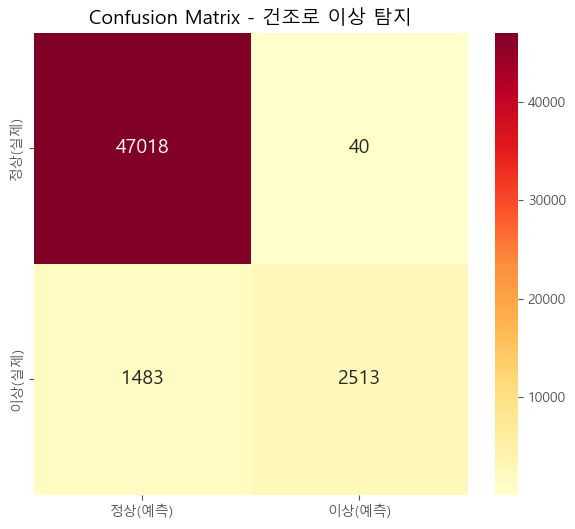


=== Classification Report ===
              precision    recall  f1-score   support

          정상       0.97      1.00      0.98     47058
          이상       0.98      0.63      0.77      3996

    accuracy                           0.97     51054
   macro avg       0.98      0.81      0.88     51054
weighted avg       0.97      0.97      0.97     51054



In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, f1_score

# Confusion Matrix
threshold = np.percentile(mse, 95)
pred_labels = (mse > threshold).astype(int)

cm = confusion_matrix(test_labels, pred_labels)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd',
            xticklabels=['정상(예측)', '이상(예측)'],
            yticklabels=['정상(실제)', '이상(실제)'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix - 건조로 이상 탐지', fontsize=14)
plt.show()

print('\n=== Classification Report ===')
print(classification_report(test_labels, pred_labels, target_names=['정상', '이상']))

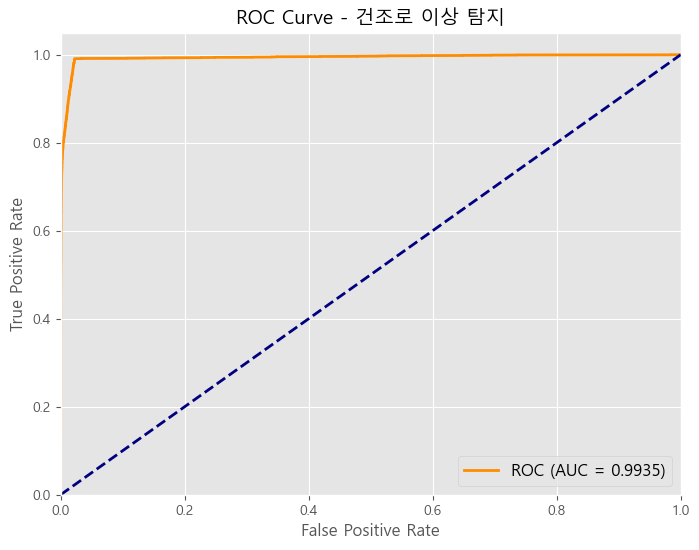

AUC: 0.9935


In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, mse)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 건조로 이상 탐지', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

print(f'AUC: {roc_auc:.4f}')

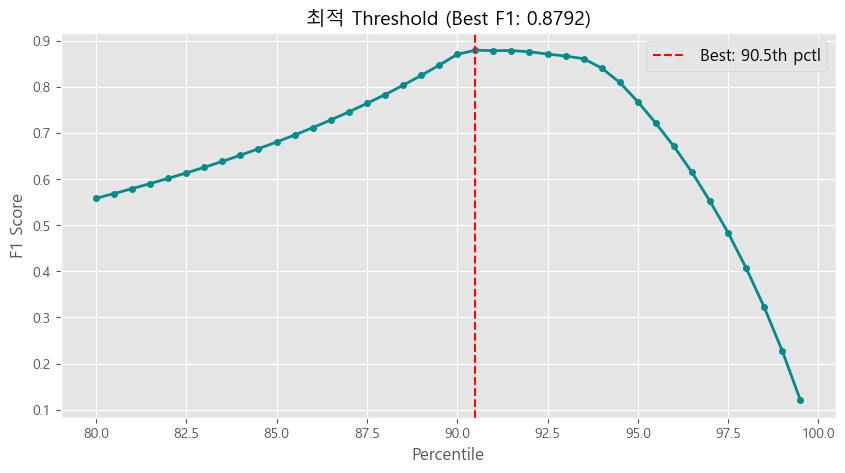

최적 Threshold: 0.157360 (90.5th percentile)

=== 최종 평가 ===
              precision    recall  f1-score   support

          정상       1.00      0.98      0.99     47058
          이상       0.80      0.97      0.88      3996

    accuracy                           0.98     51054
   macro avg       0.90      0.98      0.93     51054
weighted avg       0.98      0.98      0.98     51054



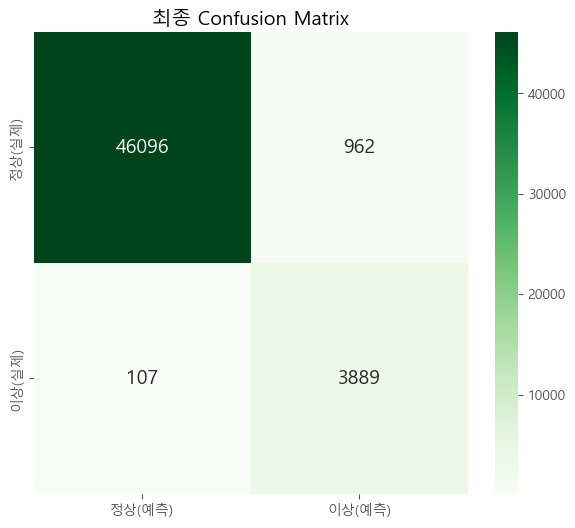

In [17]:
# 최적 Threshold 탐색
percentiles = np.arange(80, 100, 0.5)
thresholds_range = np.percentile(mse, percentiles)
f1_scores = []

for thr in thresholds_range:
    pred = (mse > thr).astype(int)
    f1_scores.append(f1_score(test_labels, pred, zero_division=0))

best_idx = np.argmax(f1_scores)
best_threshold = thresholds_range[best_idx]
best_f1 = f1_scores[best_idx]

plt.figure(figsize=(10, 5))
plt.plot(percentiles, f1_scores, marker='o', markersize=4, linewidth=2, color='darkcyan')
plt.axvline(x=percentiles[best_idx], color='red', linestyle='--',
            label=f'Best: {percentiles[best_idx]:.1f}th pctl')
plt.xlabel('Percentile')
plt.ylabel('F1 Score')
plt.title(f'최적 Threshold (Best F1: {best_f1:.4f})', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True)
plt.show()

# 최종 평가
final_pred = (mse > best_threshold).astype(int)
print(f'최적 Threshold: {best_threshold:.6f} ({percentiles[best_idx]:.1f}th percentile)')
print(f'\n=== 최종 평가 ===')
print(classification_report(test_labels, final_pred, target_names=['정상', '이상']))

cm_final = confusion_matrix(test_labels, final_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['정상(예측)', '이상(예측)'],
            yticklabels=['정상(실제)', '이상(실제)'],
            annot_kws={'size': 14})
plt.title('최종 Confusion Matrix', fontsize=14)
plt.show()

## 8. 자동차 도장 건조공정 적용 시사점

### 분석 결과
- KAMP 열풍건조 데이터를 자동차 도장 건조 조건(90°C~130°C)으로 변환하여 분석
- LSTM-AutoEncoder로 정상 건조 패턴 학습 → 이상 탐지 수행

### 자동차 도장 건조로 특수 고려사항
| 항목 | 내용 |
|---|---|
| 건조 온도 | 130°C (피크) → 90°C (서냉), 급격한 온도 변화 시 도막 불량 |
| 히터 전류 | 15A~25A, 히터 열화 시 전류 패턴 변화 |
| Zone 관리 | 건조로 내 구간별 온도 균일성 확보 필수 |
| 이상 유형 | 히터 단선, 순환팬 고장, 단열재 열화, 컨베이어 속도 이상 |

### 실제 적용 시 추가 수집 권장 데이터
1. **순환팬 진동/소음** - 베어링 마모 탐지
2. **배기 온도** - 열 효율 변화 모니터링
3. **도막 두께 측정값** - 건조 품질 직접 연관
4. **컨베이어 속도** - 건조 시간 일관성 확인
5. **외기 온도/습도** - 계절별 보정 필요

### 현장 적용 프로세스
1. PLC/SCADA에서 실시간 온도·전류 수집 (5초 주기)
2. 150초(30-step) 윈도우 단위로 모델 입력
3. Reconstruction Error > 임계값 시 **경보 발생**
4. Zone별 이상 위치 특정 → 해당 구간 점검
5. 예방 정비 일정 수립